# Exploratory Data Analysis (EDA)

## Dataset: Dim_Remote_Work

### Objective

Analyze how organizations adopted remote work before and during COVID-19, including organizational support, employee preferences, collaboration, and remote work policies.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [3]:
df_remote = pd.read_excel("../Data/Processed 2020/2. Dim_Remote_Work.xlsx")

In [4]:
df_remote.head()

,remote_work_time_last_year,org_encouraged_remote_last_year,org_prepared_remote_last_year,remote_common_last_year,remote_permission_last_year,remote_collaboration_last_year,recommend_remote_last_year,preferred_remote_time_last_year,remote_work_time_last_3_months,org_encouraged_remote_3_months,org_prepared_remote_3_months,remote_common_3_months,remote_permission_3_months
0,0.1,NaN,NaN,NaN,NaN,NaN,NaN,0.1,0.1,NaN,NaN,Neither agree nor disagree,Strongly agree
1,0.1,NaN,NaN,NaN,NaN,NaN,NaN,0.1,0.1,NaN,NaN,Strongly agree,Strongly agree
2,0.1,NaN,NaN,NaN,NaN,NaN,NaN,0.1,0.1,NaN,NaN,Strongly disagree,Neither agree nor disagree
3,0.1,NaN,NaN,NaN,NaN,NaN,NaN,0.1,0.1,NaN,NaN,Neither agree nor disagree,Strongly agree
4,0.1,NaN,NaN,NaN,NaN,NaN,NaN,0.1,0.1,NaN,NaN,Strongly agree,Strongly agree


In [5]:
df_remote.dtypes

remote_work_time_last_year         object
org_encouraged_remote_last_year    object
org_prepared_remote_last_year      object
remote_common_last_year            object
remote_permission_last_year        object
remote_collaboration_last_year     object
recommend_remote_last_year         object
preferred_remote_time_last_year    object
remote_work_time_last_3_months     object
org_encouraged_remote_3_months     object
org_prepared_remote_3_months       object
remote_common_3_months             object
remote_permission_3_months         object
dtype: object

In [6]:
df_remote.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1507 entries, 0 to 1506
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   remote_work_time_last_year       1507 non-null   object
 1   org_encouraged_remote_last_year  1257 non-null   object
 2   org_prepared_remote_last_year    1257 non-null   object
 3   remote_common_last_year          1257 non-null   object
 4   remote_permission_last_year      1257 non-null   object
 5   remote_collaboration_last_year   1257 non-null   object
 6   recommend_remote_last_year       1257 non-null   object
 7   preferred_remote_time_last_year  1507 non-null   object
 8   remote_work_time_last_3_months   1507 non-null   object
 9   org_encouraged_remote_3_months   1476 non-null   object
 10  org_prepared_remote_3_months     1476 non-null   object
 11  remote_common_3_months           1476 non-null   object
 12  remote_permission_3_months       1

In [7]:
df_remote.shape

(1507, 13)

In [8]:
df_remote.describe(include= "all").T

,count,unique,top,freq
remote_work_time_last_year,1507,12,Less than 10% of my time,268
org_encouraged_remote_last_year,1257,5,Somewhat agree,366
org_prepared_remote_last_year,1257,5,Somewhat agree,492
remote_common_last_year,1257,5,Somewhat agree,414
remote_permission_last_year,1257,5,Somewhat agree,431
remote_collaboration_last_year,1257,5,Somewhat agree,556
recommend_remote_last_year,1257,5,Somewhat agree,514
preferred_remote_time_last_year,1507,12,50% - About half of my time,300
remote_work_time_last_3_months,1507,12,100% - I spent all of my time remote working,543
org_encouraged_remote_3_months,1476,5,Strongly agree,736


In [9]:
df_remote.isnull().sum()

remote_work_time_last_year           0
org_encouraged_remote_last_year    250
org_prepared_remote_last_year      250
remote_common_last_year            250
remote_permission_last_year        250
remote_collaboration_last_year     250
recommend_remote_last_year         250
preferred_remote_time_last_year      0
remote_work_time_last_3_months       0
org_encouraged_remote_3_months      31
org_prepared_remote_3_months        31
remote_common_3_months              31
remote_permission_3_months          31
dtype: int64

### Observation

- Check for missing values in all remote work related columns.
- Handle missing values if required before analysis.

In [10]:
df_remote.duplicated().sum()

np.int64(1020)

### Observation

- Verify that no duplicate records exist.

## Q1. How much time did employees work remotely in the last year?

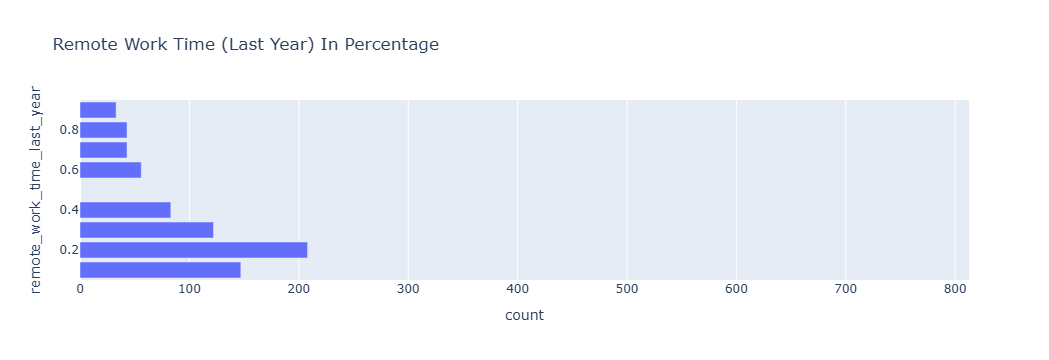

In [12]:
import plotly.express as px

# Count values and preserve order (descending frequency)
remote_work_counts = df_remote['remote_work_time_last_year'].value_counts().reset_index()
remote_work_counts.columns = ['remote_work_time_last_year', 'count']

# Create horizontal bar chart
fig = px.bar(
    remote_work_counts,
    x='count',
    y='remote_work_time_last_year',
    orientation='h',
    title='Remote Work Time (Last Year) In Percentage'
)

# Keep bars ordered by descending frequency (top to bottom)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})

fig.show()

### Insights

- This visualization shows how frequently employees worked remotely over the previous year before the survey period.
- A higher concentration in lower remote-work categories suggests that working from home was not widely adopted before COVID-19.
- If most responses fall into higher remote-work categories, it indicates that organizations had already embraced flexible work arrangements before the pandemic.
- The results provide a baseline for comparing remote work adoption before and during COVID-19.
- This insight helps businesses understand how rapidly work patterns changed when remote work became necessary.

## Q2. Did organizations encourage remote work?

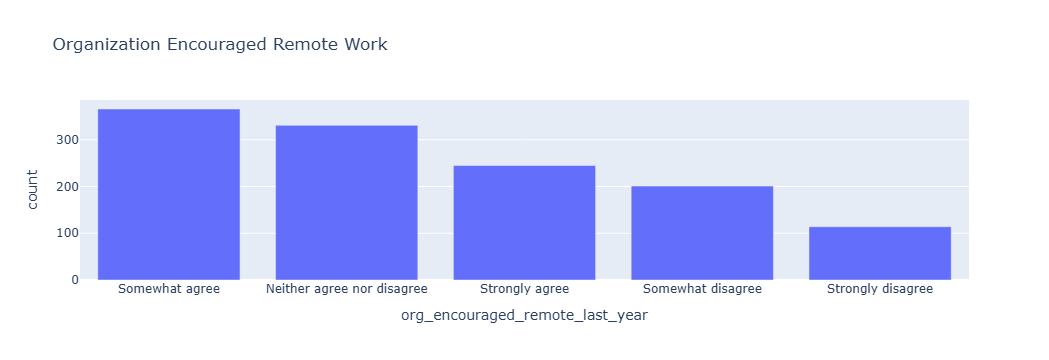

In [13]:
# Count values (no custom order specified, uses default order)
org_encouraged_counts = df_remote['org_encouraged_remote_last_year'].value_counts().reset_index()
org_encouraged_counts.columns = ['org_encouraged_remote_last_year', 'count']

# Create bar chart
fig = px.bar(
    org_encouraged_counts,
    x='org_encouraged_remote_last_year',
    y='count',
    title='Organization Encouraged Remote Work'
)

fig.show()

### Insights

- This chart measures whether organizations actively encouraged employees to work remotely before COVID-19.
- A higher number of "Yes" responses indicates that organizations had supportive remote work policies before the pandemic.
- If "No" dominates, it suggests that most organizations relied heavily on office-based work before COVID-19.
- Organizational encouragement reflects management's willingness to adopt flexible working arrangements.
- Comparing this with later pandemic data will reveal how organizational policies evolved during the crisis.

## Q3. Were organizations prepared for remote work?

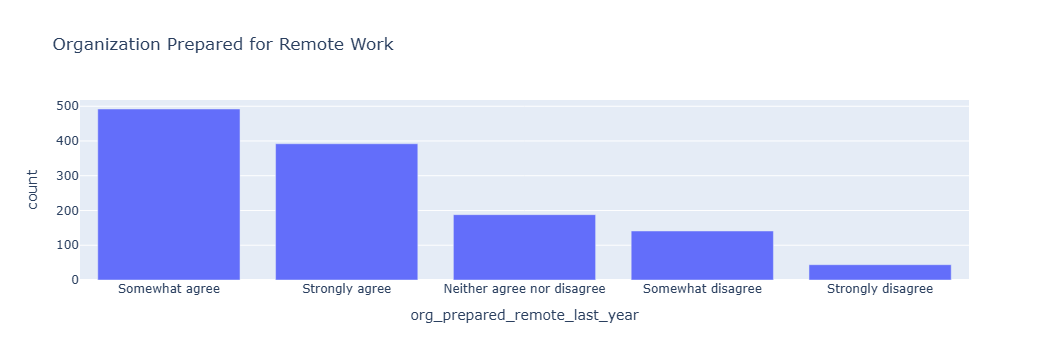

In [14]:
# Count values (no custom order specified, uses default order)
org_prepared_counts = df_remote['org_prepared_remote_last_year'].value_counts().reset_index()
org_prepared_counts.columns = ['org_prepared_remote_last_year', 'count']

# Create bar chart
fig = px.bar(
    org_prepared_counts,
    x='org_prepared_remote_last_year',
    y='count',
    title='Organization Prepared for Remote Work'
)

fig.show()

### Insights

- This visualization evaluates how prepared organizations were for remote work before COVID-19.
- Prepared organizations are more likely to have digital infrastructure, communication tools, and established remote work policies.
- A high number of unprepared organizations indicates that many businesses faced challenges when shifting to remote work.
- Organizational preparedness is expected to influence employee productivity and overall remote work experience.
- These findings highlight the importance of business continuity planning and digital transformation.

## Q4. Was remote work commonly practiced before COVID-19?

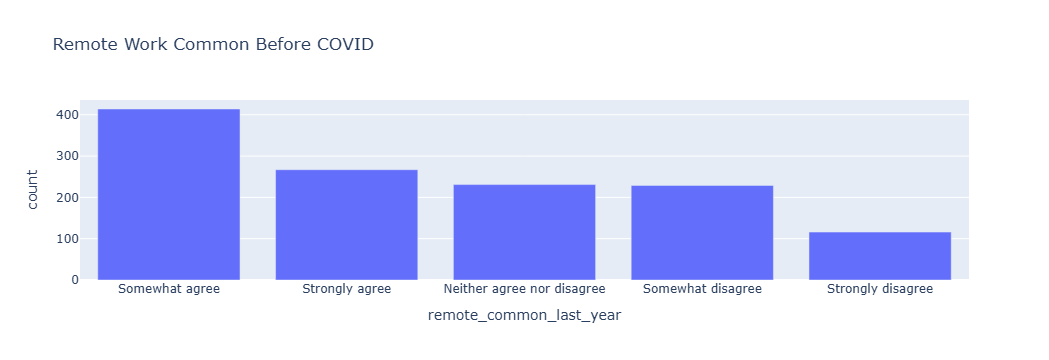

In [15]:
# Count values (no custom order specified, uses default order)
remote_common_counts = df_remote['remote_common_last_year'].value_counts().reset_index()
remote_common_counts.columns = ['remote_common_last_year', 'count']

# Create bar chart
fig = px.bar(
    remote_common_counts,
    x='remote_common_last_year',
    y='count',
    title='Remote Work Common Before COVID'
)

fig.show()

### Insights

- This chart illustrates whether remote work was already a common practice within organizations before COVID-19.
- A higher percentage of "Yes" responses suggests that flexible work culture was already established.
- A majority of "No" responses indicates that the pandemic acted as the primary catalyst for remote work adoption.
- Organizations with existing remote work culture likely experienced fewer disruptions during the transition.
- Understanding previous adoption levels helps explain differences in employee experiences throughout the pandemic.

## Q5. Were employees allowed to work remotely?

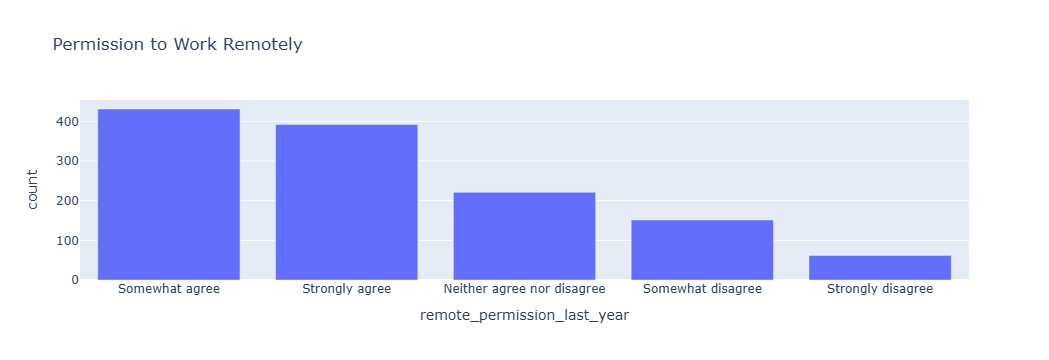

In [16]:
# Count values (no custom order specified, uses default order)
remote_permission_counts = df_remote['remote_permission_last_year'].value_counts().reset_index()
remote_permission_counts.columns = ['remote_permission_last_year', 'count']

# Create bar chart
fig = px.bar(
    remote_permission_counts,
    x='remote_permission_last_year',
    y='count',
    title='Permission to Work Remotely'
)

fig.show()

### Insights

- This visualization examines whether employees were officially permitted to work remotely before COVID-19.
- Organizations offering remote work permission demonstrate greater workplace flexibility.
- Limited permission suggests that remote work opportunities were restricted despite technological availability.
- Flexible policies may contribute to higher employee satisfaction and improved work-life balance.
- This analysis helps evaluate how company policies changed after the pandemic began.

## Q6. How well did employees collaborate while working remotely?

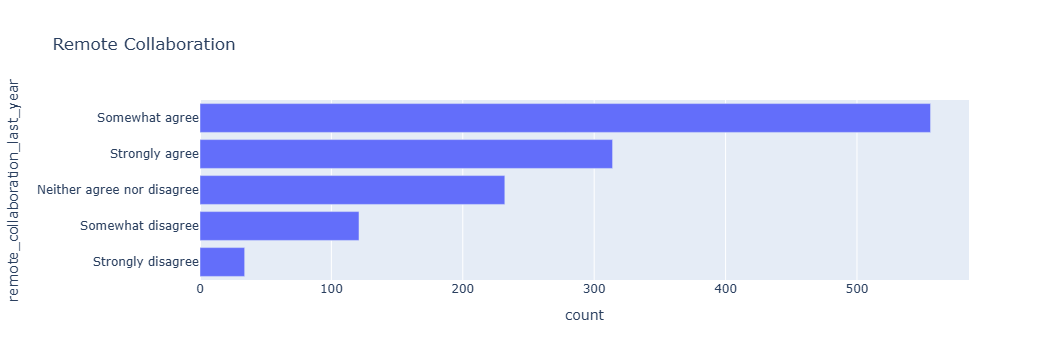

In [17]:
# Count values and preserve order (descending frequency)
remote_collab_counts = df_remote['remote_collaboration_last_year'].value_counts().reset_index()
remote_collab_counts.columns = ['remote_collaboration_last_year', 'count']

# Create horizontal bar chart
fig = px.bar(
    remote_collab_counts,
    x='count',
    y='remote_collaboration_last_year',
    orientation='h',
    title='Remote Collaboration'
)

# Keep bars ordered by descending frequency (top to bottom)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})

fig.show()

### Insights

- This chart evaluates employees' perception of collaboration while working remotely.
- Higher ratings indicate that organizations successfully maintained teamwork through digital communication platforms.
- Lower ratings may suggest challenges such as communication gaps, delayed decision-making, or reduced team interaction.
- Effective collaboration is essential for maintaining productivity in remote environments.
- These findings can guide organizations in improving communication strategies and collaboration tools.

## Q7. Would employees recommend remote work?

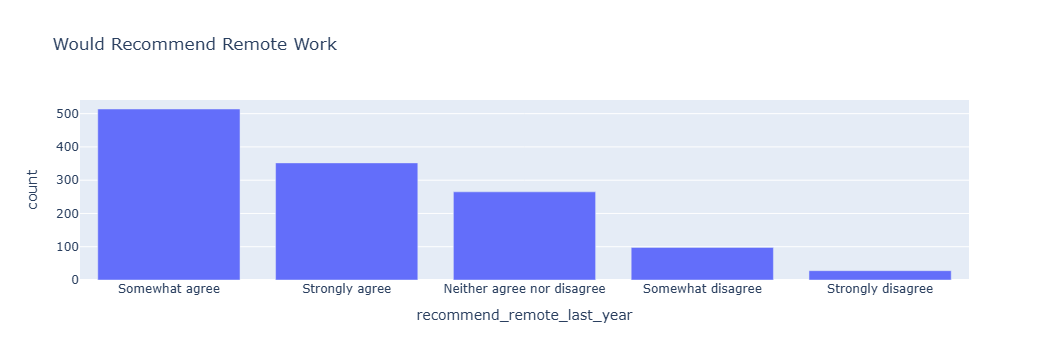

In [18]:
# Count values (no custom order specified, uses default order)
recommend_remote_counts = df_remote['recommend_remote_last_year'].value_counts().reset_index()
recommend_remote_counts.columns = ['recommend_remote_last_year', 'count']

# Create bar chart
fig = px.bar(
    recommend_remote_counts,
    x='recommend_remote_last_year',
    y='count',
    title='Would Recommend Remote Work'
)

fig.show()

### Insights

- This visualization measures employees' willingness to recommend remote work to others.
- A high recommendation rate indicates positive employee experiences and acceptance of remote work.
- Lower recommendation rates may reflect dissatisfaction caused by communication issues, isolation, or inadequate organizational support.
- Employee recommendations serve as an overall indicator of remote work success.
- Organizations can use this feedback to improve future workplace flexibility policies.

## Q8. How much remote work do employees prefer?

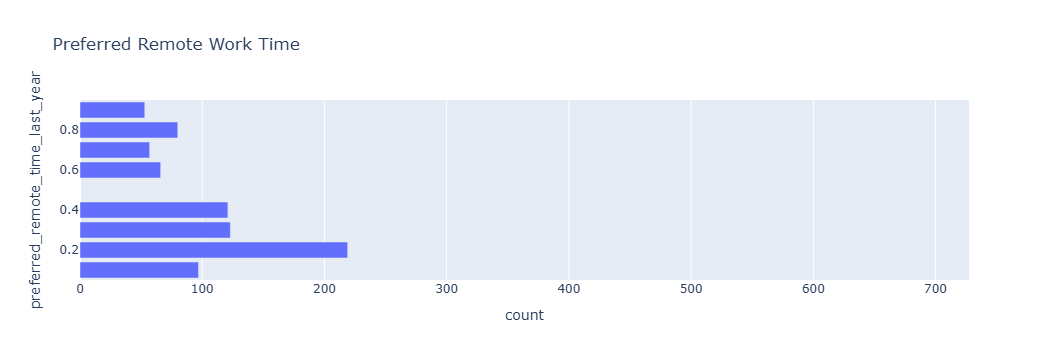

In [19]:
# Count values and preserve order (descending frequency)
preferred_remote_counts = df_remote['preferred_remote_time_last_year'].value_counts().reset_index()
preferred_remote_counts.columns = ['preferred_remote_time_last_year', 'count']

# Create horizontal bar chart
fig = px.bar(
    preferred_remote_counts,
    x='count',
    y='preferred_remote_time_last_year',
    orientation='h',
    title='Preferred Remote Work Time'
)

# Keep bars ordered by descending frequency (top to bottom)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})

fig.show()

### Insights

- This chart presents employees' preferred amount of remote work regardless of their current working arrangement.
- Preferences provide valuable insight into the future demand for remote, hybrid, or office-based work models.
- A strong preference for hybrid work may indicate employees value both flexibility and workplace collaboration.
- Organizations can use these findings to design employee-centric work policies.
- Understanding employee preferences helps improve retention, satisfaction, and organizational performance.

## Q9. How much time did employees work remotely during the last 3 months?

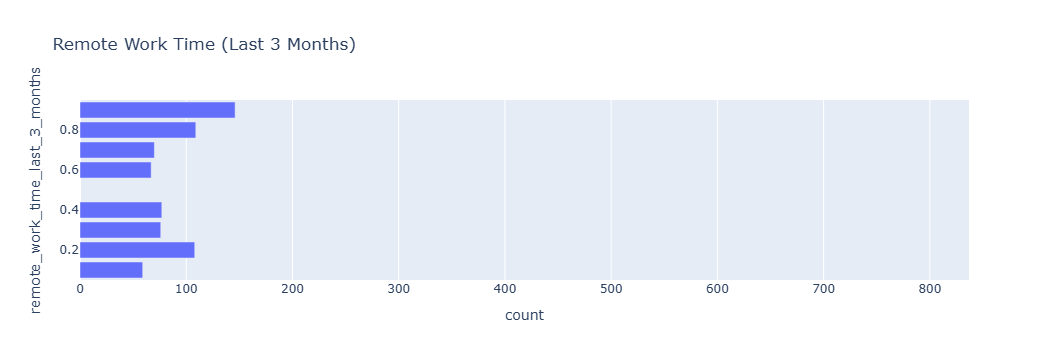

In [20]:
# Count values and preserve order (descending frequency)
remote_3months_counts = df_remote['remote_work_time_last_3_months'].value_counts().reset_index()
remote_3months_counts.columns = ['remote_work_time_last_3_months', 'count']

# Create horizontal bar chart
fig = px.bar(
    remote_3months_counts,
    x='count',
    y='remote_work_time_last_3_months',
    orientation='h',
    title='Remote Work Time (Last 3 Months)'
)

# Keep bars ordered by descending frequency (top to bottom)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})

fig.show()

### Insights

- This visualization shows how much employees worked remotely during the last three months of the survey period.
- Comparing this chart with remote work patterns from the previous year highlights the impact of COVID-19 on workplace practices.
- A noticeable increase in remote work demonstrates how rapidly organizations adapted to changing business conditions.
- The results reflect the scale of digital transformation across industries.
- This comparison forms one of the key findings of the overall project.

## Q10. Did organizational support improve during the last 3 months?

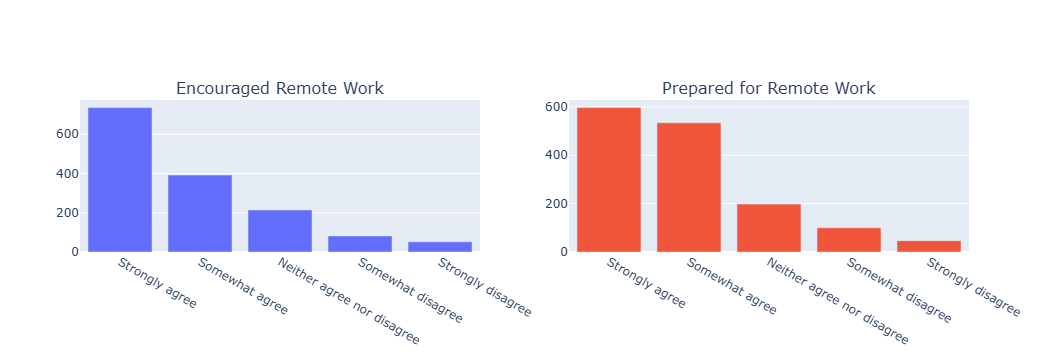

In [21]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Count values for both columns
encouraged_counts = df_remote['org_encouraged_remote_3_months'].value_counts().reset_index()
encouraged_counts.columns = ['org_encouraged_remote_3_months', 'count']

prepared_counts = df_remote['org_prepared_remote_3_months'].value_counts().reset_index()
prepared_counts.columns = ['org_prepared_remote_3_months', 'count']

# Create side-by-side subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=("Encouraged Remote Work", "Prepared for Remote Work"))

fig.add_trace(
    go.Bar(x=encouraged_counts['org_encouraged_remote_3_months'], y=encouraged_counts['count']),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=prepared_counts['org_prepared_remote_3_months'], y=prepared_counts['count']),
    row=1, col=2
)

fig.update_layout(showlegend=False)

fig.show()

### Insights

- These charts compare organizational encouragement and preparedness for remote work during the last three months.
- Increased encouragement indicates that organizations actively promoted remote work in response to COVID-19.
- Improved preparedness suggests businesses invested in digital infrastructure and remote collaboration tools.
- Together, these measures demonstrate how organizations adapted to unprecedented workplace challenges.
- This analysis helps evaluate organizational resilience during periods of disruption.

## Q11. Was remote work more common during the last 3 months?

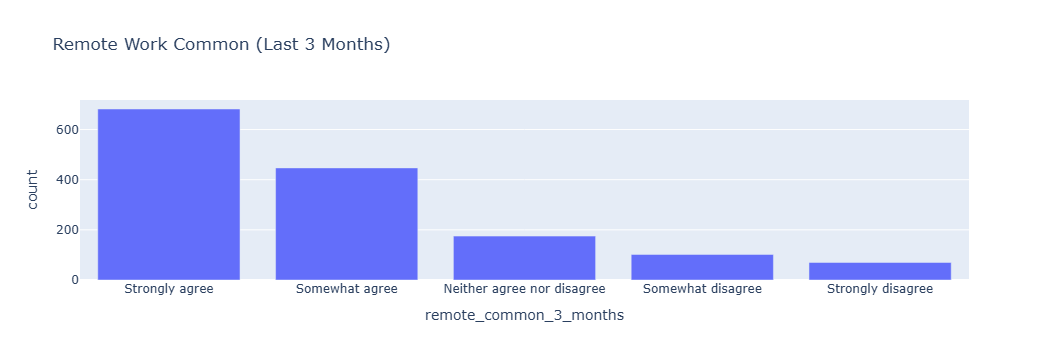

In [22]:
import plotly.express as px

# Count values (no custom order specified, uses default order)
remote_common_3m_counts = df_remote['remote_common_3_months'].value_counts().reset_index()
remote_common_3m_counts.columns = ['remote_common_3_months', 'count']

# Create bar chart
fig = px.bar(
    remote_common_3m_counts,
    x='remote_common_3_months',
    y='count',
    title='Remote Work Common (Last 3 Months)'
)

fig.show()

### Insights

- This visualization examines whether remote work became more common during the last three months.
- A higher proportion of positive responses indicates widespread adoption of remote work practices.
- Comparing this result with pre-pandemic responses illustrates the magnitude of organizational change.
- The findings highlight how rapidly businesses shifted from traditional office environments to remote work.
- This serves as a key indicator of changing workplace culture during COVID-19.

## Q12. Were employees allowed to work remotely during the last 3 months?

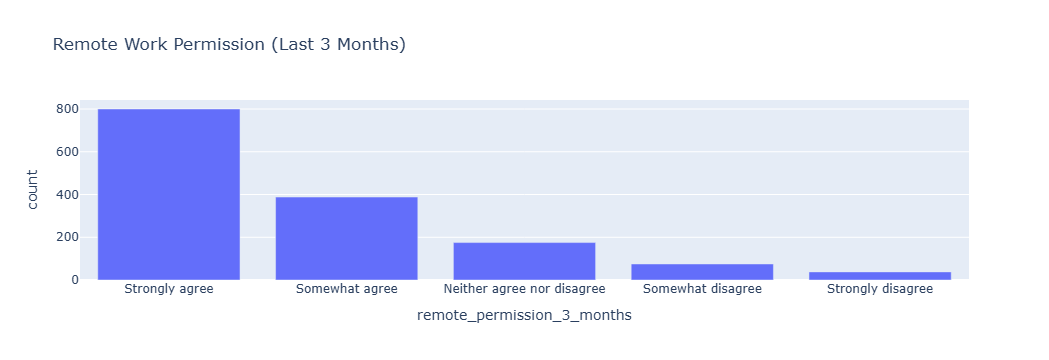

In [24]:
# Count values (no custom order specified, uses default order)
remote_permission_3m_counts = df_remote['remote_permission_3_months'].value_counts().reset_index()
remote_permission_3m_counts.columns = ['remote_permission_3_months', 'count']

# Create bar chart
fig = px.bar(
    remote_permission_3m_counts,
    x='remote_permission_3_months',
    y='count',
    title='Remote Work Permission (Last 3 Months)'
)

fig.show()

### Insights

- This chart measures whether employees were permitted to work remotely during the last three months.
- An increase in remote work permission reflects greater organizational flexibility during the pandemic.
- Companies that expanded remote work opportunities were better positioned to maintain business operations.
- This analysis demonstrates how workplace policies evolved in response to external challenges.
- The findings provide evidence of long-term changes in organizational work practices.

# Key Findings

- Remote work adoption increased significantly during COVID-19 compared to the previous year.
- Organizations became more supportive and better prepared for remote work during the pandemic.
- Flexible work policies expanded as businesses adapted to changing conditions.
- Employee collaboration remained an important factor influencing successful remote work.
- Most employees expressed clear preferences regarding future remote or hybrid work arrangements.
- The comparison between pre-pandemic and pandemic responses demonstrates a major shift in workplace culture and organizational policies.